# Python DSP Alpha Build : Tascam 414 mkII-Emulation

Documentation of early development of a portastudio inspired saturation VST plugin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def rms(x):
    return np.sqrt(np.mean(x**2))

## 1. Base Signal Setup
a 1kHz sine wave is used as a test signal to observe the effects of saturation in time and frequency domains

In [2]:
fs = 44100
duration = 0.05
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

f = 1000
drive = 4.0
signal = np.sin(2 * np.pi * f * t)

## 2. Saturation Stage
Saturation and harmonic content are introduced by applying a tanh nonlinearity after increasing input with a drive parameter

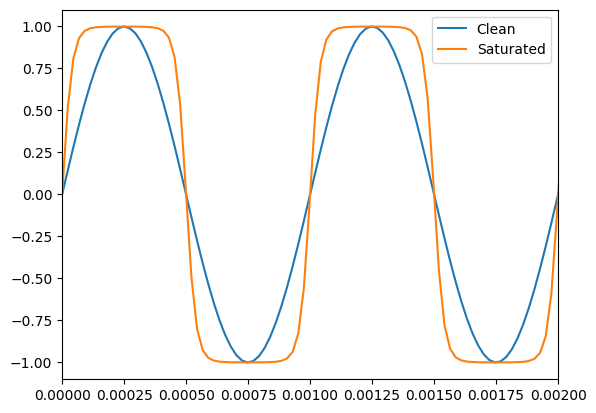

In [3]:
y = np.tanh(drive * signal)

plt.plot(t, signal, label="Clean")
plt.plot(t, y, label="Saturated")
plt.xlim(0, 0.002)
plt.legend()
plt.show()

## 3. FFT Analysis
FFT is used to compare clean and saturated signals and show associated harmonics created by the nonlinear processing

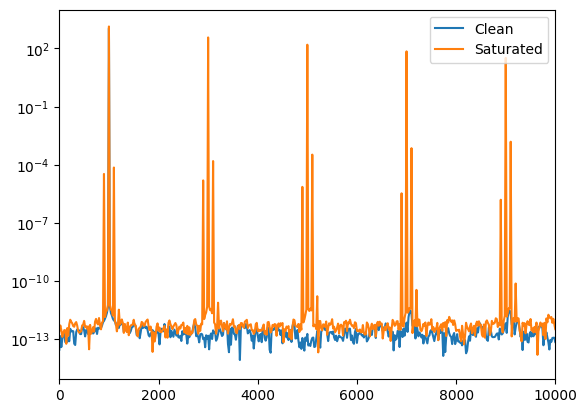

In [4]:
N = len(signal)
xf = fftfreq(N, 1 / fs)

clean_fft = np.abs(fft(signal))
sat_fft = np.abs(fft(y))

plt.plot(xf[:N // 2], clean_fft[:N // 2], label="Clean")
plt.plot(xf[:N // 2], sat_fft[:N // 2], label="Saturated")
plt.xlim(0, 10000)
plt.yscale("log")
plt.legend()
plt.show()

## 4. Autogain
An RMS based makeupgain is to match the level of the processed signal to the original.

In [5]:
autogain = True

rms_clean = rms(signal)
rms_sat = rms(y)

makeup = rms_clean / rms_sat

if autogain:
    y_out = y * makeup
else:
    y_out = y

print("Clean RMS:", rms_clean)
print("Output RMS:", rms(y_out))

Clean RMS: 0.7071067811865476
Output RMS: 0.7071067811865477


### Effect of Autogain on Spectrum
FFT to confirm there are no changes to harmonic structure, only the overall level.

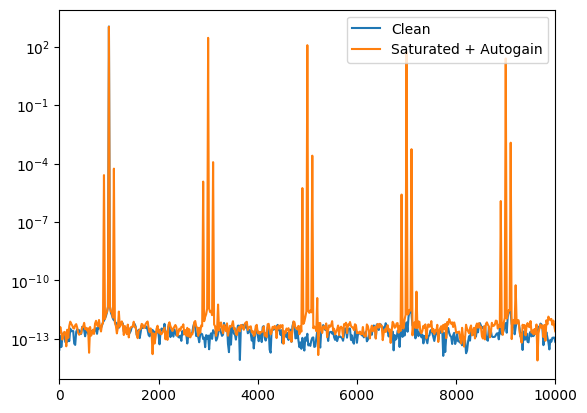

In [6]:
out_fft = np.abs(fft(y_out))

plt.plot(xf[:N // 2], clean_fft[:N // 2], label="Clean")
plt.plot(xf[:N // 2], out_fft[:N // 2], label="Saturated + Autogain")
plt.xlim(0, 10000)
plt.yscale("log")
plt.legend()
plt.show()

## 5. Dry/Wet Mix
Mix control to blend processed and clean signals allowing for parallel processing.

In [7]:
mix = 0.5
y_mix = (1 - mix) * signal + mix * y_out

print("RMS Clean:", rms(signal))
print("RMS Mix:", rms(y_mix))
print("RMS Wet:", rms(y_out))

RMS Clean: 0.7071067811865476
RMS Mix: 0.6995796089384645
RMS Wet: 0.7071067811865477


## 6. Mix Verification
Checks the mix control behaves correctly. A mix = 0 the output should match the clean signal and at mix = 1 it should match the processed signal

In [8]:
mix = 0.0
y_mix_0 = (1 - mix) * signal + mix * y_out
print("RMS @ mix 0:", rms(y_mix_0))

mix = 1.0
y_mix_1 = (1 - mix) * signal + mix * y_out
print("RMS @ mix 1:", rms(y_mix_1))

RMS @ mix 0: 0.7071067811865476
RMS @ mix 1: 0.7071067811865477


In [9]:
# Restore working mix
mix = 0.5
y_mix = (1 - mix) * signal + mix * y_out

## 7. Tone Filter
First order low-pass filter applied after mix stage to smooth high frequency content produced by the saturation

0.5746551995630436


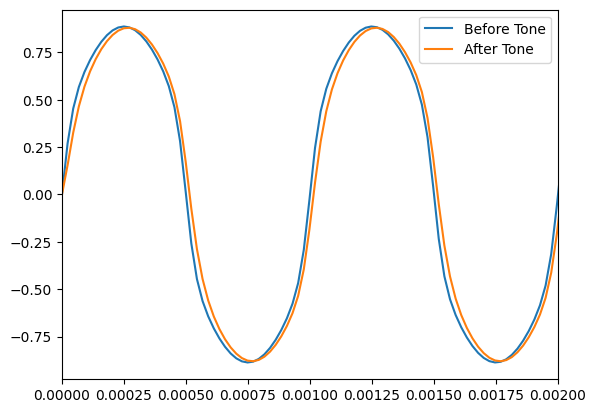

In [10]:
fc = 6000
alpha = 1 - np.exp(-2 * np.pi * fc / fs)
print(alpha)

y_tone = np.zeros_like(y_mix)
y_tone[0] = y_mix[0]

for n in range(1, len(y_mix)):
    y_tone[n] = y_tone[n - 1] + alpha * (y_mix[n] - y_tone[n - 1])

plt.plot(t, y_mix, label="Before Tone")
plt.plot(t, y_tone, label="After Tone")
plt.xlim(0, 0.002)
plt.legend()
plt.show()

## 7. Aliasing Demonstration
Aliasing artifacts are made more visible in the frequency spectrum with the use of a higher-frequency signal and stronger drive

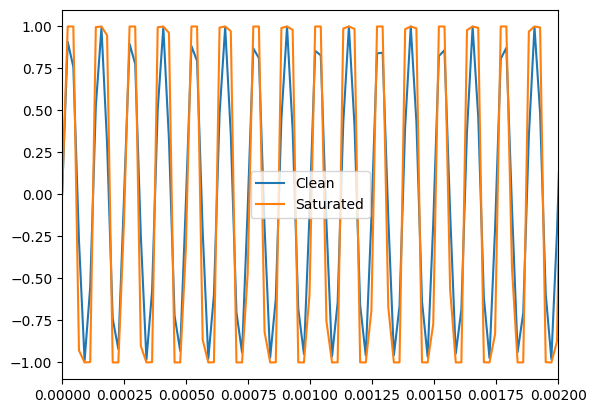

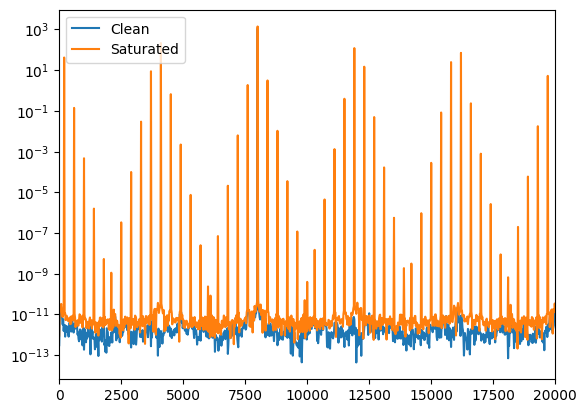

In [11]:
t_alias = np.linspace(0, duration, int(fs * duration), endpoint=False)
f_alias = 8000
drive_alias = 6.0

signal_alias = np.sin(2 * np.pi * f_alias * t_alias)
y_alias = np.tanh(drive_alias * signal_alias)

plt.plot(t_alias, signal_alias, label="Clean")
plt.plot(t_alias, y_alias, label="Saturated")
plt.xlim(0, 0.002)
plt.legend()
plt.show()

N_alias = len(signal_alias)
xf_alias = fftfreq(N_alias, 1 / fs)

clean_fft_alias = np.abs(fft(signal_alias))
sat_fft_alias = np.abs(fft(y_alias))

plt.plot(xf_alias[:N_alias // 2], clean_fft_alias[:N_alias // 2], label="Clean")
plt.plot(xf_alias[:N_alias // 2], sat_fft_alias[:N_alias // 2], label="Saturated")
plt.xlim(0, 20000)
plt.yscale("log")
plt.legend()
plt.show()

## 8. Oversampling Prototype
A simple 2x oversampling process is implemented to reduce aliasing:

Upsample
Saturation Application
Low-pass filter
Downsample

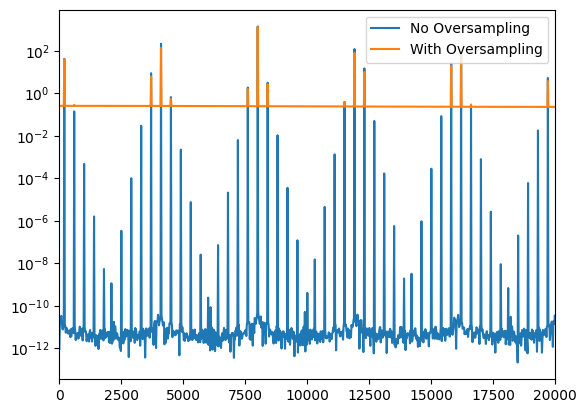

In [12]:
# Oversampling prototype
N_os = len(signal_alias)
upsampled = np.zeros(2 * N_os - 1)

for i in range(N_os - 1):
    upsampled[2 * i] = signal_alias[i]
    upsampled[2 * i + 1] = (signal_alias[i] + signal_alias[i + 1]) / 2

upsampled[-1] = signal_alias[-1]

y_os = np.tanh(drive_alias * upsampled)

fs_os = fs * 2
fc_os = 20000
alpha_os = 1 - np.exp(-2 * np.pi * fc_os / fs_os)

y_filt = np.zeros_like(y_os)
y_filt[0] = y_os[0]

for n in range(1, len(y_os)):
    y_filt[n] = y_filt[n - 1] + alpha_os * (y_os[n] - y_filt[n - 1])

y_ds = y_filt[::2]

N_ds = len(y_ds)
xf_ds = fftfreq(N_ds, 1 / fs)

os_fft = np.abs(fft(y_ds))

plt.plot(xf_alias[:N_alias // 2], sat_fft_alias[:N_alias // 2], label="No Oversampling")
plt.plot(xf_ds[:N_ds // 2], os_fft[:N_ds // 2], label="With Oversampling")
plt.xlim(0, 20000)
plt.yscale("log")
plt.legend()
plt.show()